In [278]:
import pandas as pd
from canexao import connect_to_mongo
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import json



sns.set_theme(style="whitegrid")

collection_users, collection_tasks = connect_to_mongo()
tabela_users = pd.DataFrame(list(collection_users.find()))
tabela = pd.DataFrame(list(collection_tasks.find()))





Conexão estabelecida com sucesso!


In [279]:
tabela.head()

,_id,task_id,titulo,descricao,prioridade,user_id,mentorado,area_atuacao,mentor_responsavel,data_criacao,data_inicio,status_atual,data_conclusao,feedback_conclusao_mentorado,createdAt,updatedAt,__v
0,6a2b884993a2aac46c8ba14a,1.0,Otimizar Microsserviços - Sprint 8,Atividade focada em otimizar o recurso de micr...,media,6a2b8445cf36b576d237ae6b,Bruno Costa,DevBack-end,Juliana Costa,2026-05-05,2026-05-07,andamento,NaT,NaN,NaT,NaT,NaN
1,6a2b884993a2aac46c8ba14b,2.0,Testar Scripts de Deploy - Sprint 2,Atividade focada em testar o recurso de script...,alta,6a2b8468cf36b576d237ae6c,Felipe Andrade,QA,Juliana Costa,2026-03-25,2026-03-27,concluida,2026-04-02,Os testes cobriram os cenários críticos de aut...,NaT,NaT,NaN
2,6a2b884993a2aac46c8ba14c,3.0,Testar Cache em Redis - Sprint 2,Atividade focada em testar o recurso de cache ...,media,6a2b8468cf36b576d237ae6c,Felipe Andrade,QA,Juliana Costa,2026-03-26,2026-03-27,concluida,2026-04-06,Validação executada com sucesso. O fluxo corre...,NaT,NaT,NaN
3,6a2b884993a2aac46c8ba14d,4.0,Testar Componentes React - Sprint 8,Atividade focada em testar o recurso de compon...,media,6a2b8496cf36b576d237ae6d,Diego Martins,QA,Juliana Costa,2026-04-20,2026-04-21,concluida,2026-04-27,Conseguimos manter uma boa cobertura de testes...,NaT,NaT,NaN
4,6a2b884993a2aac46c8ba14e,5.0,Ajustar Exportação de Relatórios - Sprint 3,Atividade focada em ajustar o recurso de expor...,media,6a2b84b4cf36b576d237ae6e,Camila Lopes,Produto,Juliana Costa,2026-03-02,2026-03-05,concluida,2026-03-19,Os ajustes visuais foram concluídos no prazo. ...,NaT,NaT,NaN


In [280]:
# Mostra o número de linhas, colunas e o tipo de dados de cada coluna
tabela.info()

# Mostra um resumo estatístico das colunas numéricas
tabela.describe()

<class 'pandas.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   _id                           78 non-null     object        
 1   task_id                       76 non-null     float64       
 2   titulo                        78 non-null     str           
 3   descricao                     78 non-null     str           
 4   prioridade                    78 non-null     str           
 5   user_id                       78 non-null     object        
 6   mentorado                     77 non-null     str           
 7   area_atuacao                  76 non-null     str           
 8   mentor_responsavel            78 non-null     str           
 9   data_criacao                  76 non-null     datetime64[us]
 10  data_inicio                   64 non-null     datetime64[us]
 11  status_atual                  78 non-null    

,task_id,data_criacao,data_inicio,data_conclusao,createdAt,updatedAt,__v
count,76.000000,76,64,44,2,2,2.0
mean,38.500000,2026-04-18 14:31:34.736842,2026-04-15 15:00:00,2026-04-12 08:10:54.545454,2026-06-13 11:42:46.753000,2026-06-13 11:45:22.575500,0.0
min,1.000000,2026-03-01 00:00:00,2026-03-03 00:00:00,2026-03-09 00:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
25%,19.750000,2026-03-23 18:00:00,2026-03-24 06:00:00,2026-03-27 06:00:00,2026-06-12 20:07:54.974000,2026-06-12 20:11:48.707750,0.0
50%,38.500000,2026-04-28 00:00:00,2026-04-18 12:00:00,2026-04-05 12:00:00,2026-06-13 11:42:46.753000,2026-06-13 11:45:22.575500,0.0
75%,57.250000,2026-05-12 00:00:00,2026-05-09 06:00:00,2026-04-29 06:00:00,2026-06-14 03:17:38.532000,2026-06-14 03:18:56.443250,0.0
max,76.000000,2026-05-27 00:00:00,2026-06-11 00:00:00,2026-06-15 00:00:00,2026-06-14 18:52:30.311000,2026-06-14 18:52:30.311000,0.0
std,22.083176,NaN,NaN,NaN,NaN,NaN,0.0


In [281]:
# 1. Converter as colunas de data de texto para o formato de data real (datetime)
tabela['data_criacao'] = pd.to_datetime(tabela['data_criacao'], errors='coerce')
tabela['data_inicio'] = pd.to_datetime(tabela['data_inicio'], errors='coerce')
tabela['data_conclusao'] = pd.to_datetime(tabela['data_conclusao'], errors='coerce')

# 2. Criar uma coluna útil: Tempo de Resolução (em dias) entre a criação e a conclusão. Calculo para entender o ciclo de vida de uma atividade da Criação à Conclusão.
tabela['tempo_conclusao_dias'] = (tabela['data_conclusao'] - tabela['data_criacao']).dt.days

# Verificando se as transformações deram certo
tabela[['data_criacao', 'data_inicio', 'data_conclusao', 'tempo_conclusao_dias']].info()

<class 'pandas.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   data_criacao          76 non-null     datetime64[us]
 1   data_inicio           64 non-null     datetime64[us]
 2   data_conclusao        44 non-null     datetime64[us]
 3   tempo_conclusao_dias  43 non-null     float64       
dtypes: datetime64[us](3), float64(1)
memory usage: 2.6 KB


In [282]:
databcorte = pd.to_datetime('2026-05-31') 

# Inicialização segura de colunas
tabela['duracao_em_dias'] = np.nan #tempo do inicio da task ate a conclusao.
tabela['tempo_no_backlog'] = np.nan #quantidade de tempo no backlog

# 1. TEMPO DE FILA (Backlog): Da criação até o início do trabalho (ou até a datarecorte/atual, se ainda não iniciou)
tabela['tempo_no_backlog'] = np.where(
    tabela['status_atual'] == 'pendente',
    (databcorte - tabela['data_criacao']).dt.days,
    (tabela['data_inicio'] - tabela['data_criacao']).dt.days
)

# 2. TEMPO DE EXECUÇÃO : Do início do trabalho até a conclusão (ou até a datarecorte/atual, se ainda não iniciouu ou concluiu)
task_concluida = tabela['status_atual'] == 'concluida'
tabela.loc[task_concluida, 'duracao_em_dias'] = (tabela.loc[task_concluida, 'data_conclusao'] - tabela.loc[task_concluida, 'data_inicio']).dt.days

task_andamento = tabela['status_atual'] == 'andamento'
tabela.loc[task_andamento, 'duracao_em_dias'] = (databcorte - tabela.loc[task_andamento, 'data_inicio']).dt.days

# Tarefas pendentes ainda não começaram a ser executadas (Tempo de execução = 0)
task_pendente = tabela['status_atual'] == 'pendente'
tabela.loc[task_pendente, 'duracao_em_dias'] = 0

print(tabela[['titulo', 'status_atual', 'duracao_em_dias', 'tempo_no_backlog']].head(10))

                                        titulo status_atual  duracao_em_dias  \
0           Otimizar Microsserviços - Sprint 8    andamento             24.0   
1          Testar Scripts de Deploy - Sprint 2    concluida              6.0   
2             Testar Cache em Redis - Sprint 2    concluida             10.0   
3          Testar Componentes React - Sprint 8    concluida              6.0   
4  Ajustar Exportação de Relatórios - Sprint 3    concluida             14.0   
5  Documentar Acessibilidade (WCAG) - Sprint 7    andamento             24.0   
6               Criar API de Login - Sprint 10     pendente              0.0   
7           Criar Scripts de Deploy - Sprint 2    concluida              9.0   
8   Atualizar Acessibilidade (WCAG) - Sprint 1    andamento             24.0   
9                   Criar Dashboard - Sprint 1    concluida             11.0   

   tempo_no_backlog  
0               2.0  
1               2.0  
2               1.0  
3               1.0  
4        

In [283]:
tabela['tempo_conclusao_dias'].describe()

count    43.000000
mean     12.697674
std       5.307384
min       4.000000
25%       8.000000
50%      12.000000
75%      17.000000
max      23.000000
Name: tempo_conclusao_dias, dtype: float64

In [284]:
#Metricas que consideram o ciclo de vida : da criação a conclusão.
# 1. Média de dias para concluir uma tarefa( no sentido de entender o ciclo de vida de uma atividade da Criação à Conclusão).
media_dias = tabela['tempo_conclusao_dias'].mean()
mediana_dias = tabela['tempo_conclusao_dias'].median()
max_dias = tabela['tempo_conclusao_dias'].max()
total_tarefas_submetidas = tabela['status_atual'].count()

print(f"⏱️ Tempo Médio de Conclusão: {media_dias:.1f} dias") #ciclo de vida da atividade da criação à conclusão
print(f"🎯 Mediana do Tempo (50% das tarefas): {mediana_dias:.1f} dias")#tiraria esta aqui
print(f"🚨 Tarefa mais demorada levou: {max_dias:.1f} dias")
print(f"✅ Total de Tarefas Submetidas: {total_tarefas_submetidas}") #sugestao de card para dashboard
print("-" * 50)

# 2. Qual área de atuação demora mais para concluir as tarefas?
print("🐢 Tempo médio de conclusão por ÁREA DE ATUAÇÃO:")
print(tabela.groupby('area_atuacao')['tempo_conclusao_dias'].mean().sort_values(ascending=False))
print("-" * 50)

# 3. Qual nível de prioridade está levando mais tempo?
print("⚠️ Tempo médio de conclusão por PRIORIDADE:")
print(tabela.groupby('prioridade')['tempo_conclusao_dias'].mean().sort_values(ascending=False))

⏱️ Tempo Médio de Conclusão: 12.7 dias
🎯 Mediana do Tempo (50% das tarefas): 12.0 dias
🚨 Tarefa mais demorada levou: 23.0 dias
✅ Total de Tarefas Submetidas: 78
--------------------------------------------------
🐢 Tempo médio de conclusão por ÁREA DE ATUAÇÃO:
area_atuacao
Data Engineer    15.200000
DevBack-end      13.857143
QA               12.500000
UX/UIDesigner    12.000000
DevMobile        10.800000
Produto          10.666667
DevFront-end     10.571429
Name: tempo_conclusao_dias, dtype: float64
--------------------------------------------------
⚠️ Tempo médio de conclusão por PRIORIDADE:
prioridade
media    13.157895
alta     12.533333
baixa    12.000000
Name: tempo_conclusao_dias, dtype: float64


In [285]:
# 1. Distribuição Geral dos Status (Quantidade e Percentual)
print("📊 DISTRIBUIÇÃO GERAL DOS STATUS:")
status_qtd = tabela['status_atual'].value_counts()
status_pct = tabela['status_atual'].value_counts(normalize=True) * 100

for status in status_qtd.index:
    print(f"• {status}: {status_qtd[status]} tarefas ({status_pct[status]:.1f}%)")
print("-" * 50)

# 2. Quais áreas têm mais tarefas que ainda NÃO foram concluídas?
# Filtrando onde a data de conclusão está vazia (NaN)
print("⏳ TAREFAS PENDENTES (Não concluídas) POR ÁREA DE ATUAÇÃO:")
pendentes_por_area = tabela[tabela['data_conclusao'].isna()]['area_atuacao'].value_counts()
print(pendentes_por_area)
print("-" * 50)

# 3. Cruzamento: Quem está cuidando de quais status?
print("🤝 STATUS DAS TAREFAS POR MENTOR RESPONSÁVEL:")
print(pd.crosstab(tabela['mentor_responsavel'], tabela['status_atual']))

📊 DISTRIBUIÇÃO GERAL DOS STATUS:
• concluida: 44 tarefas (56.4%)
• andamento: 19 tarefas (24.4%)
• pendente: 15 tarefas (19.2%)
--------------------------------------------------
⏳ TAREFAS PENDENTES (Não concluídas) POR ÁREA DE ATUAÇÃO:
area_atuacao
QA               9
Data Engineer    6
DevMobile        5
Produto          4
DevBack-end      3
UX/UIDesigner    3
DevFront-end     3
Name: count, dtype: int64
--------------------------------------------------
🤝 STATUS DAS TAREFAS POR MENTOR RESPONSÁVEL:
status_atual        andamento  concluida  pendente
mentor_responsavel                                
Juliana Costa              19         44        14
fdf                         0          0         1


C:\Users\lmm4\AppData\Local\Temp\ipykernel_25732\1350028386.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pendentes_por_area.values, y=pendentes_por_area.index, palette="danger_r" if "danger_r" in dir(sns.color_palette) else "Reds_r")


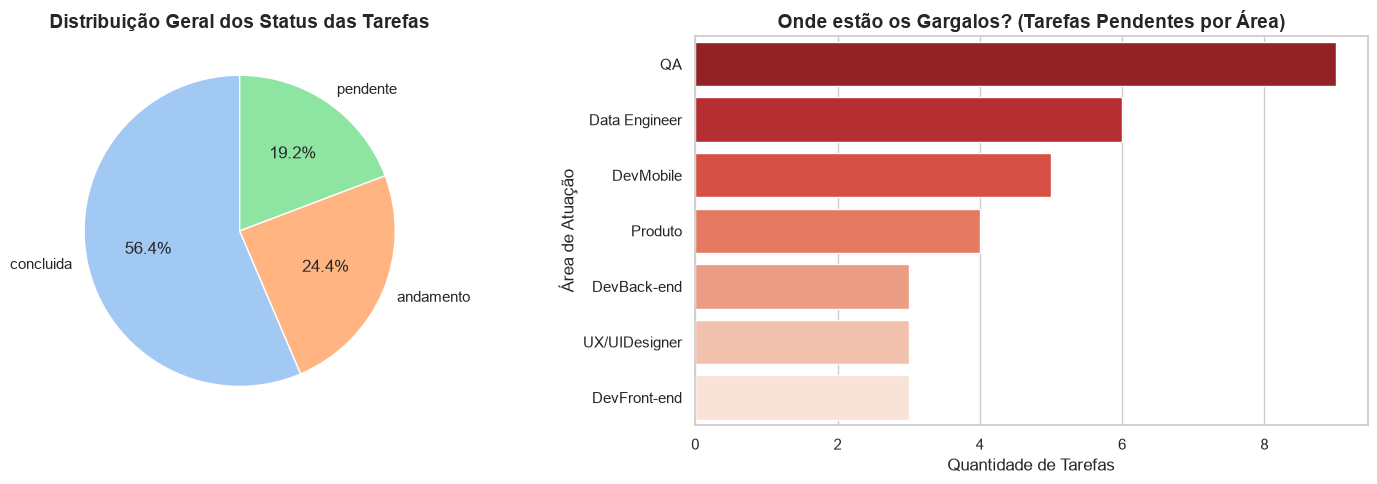

In [286]:
import json 


# Configurando o estilo dos gráficos

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# Gráfico 1: Distribuição de Status
plt.subplot(1, 2, 1)
status_cores = sns.color_palette("pastel")[0:3]
plt.pie(status_qtd, labels=status_qtd.index, autopct='%1.1f%%', startangle=90, colors=status_cores)
plt.title("Distribuição Geral dos Status das Tarefas", fontsize=14, fontweight='bold')

# Gráfico 2: Tarefas Pendentes por Área
plt.subplot(1, 2, 2)
sns.barplot(x=pendentes_por_area.values, y=pendentes_por_area.index, palette="danger_r" if "danger_r" in dir(sns.color_palette) else "Reds_r")
plt.title("Onde estão os Gargalos? (Tarefas Pendentes por Área)", fontsize=14, fontweight='bold')
plt.xlabel("Quantidade de Tarefas")
plt.ylabel("Área de Atuação")

plt.tight_layout()
plt.show()

#importar todos os resultados em um arquivo JSON para facilitar a leitura e compartilhamento dos insights com o front-end/angular.
# garantir que a contagem de atrasadas exista e esteja atualizada
if 'meta_dias' in tabela.columns:
    cond_status = tabela['status_atual'].isin(['andamento', 'pendente'])
    cond_atraso = tabela['duracao_em_dias'] > tabela['meta_dias']
    atrasadas = tabela[cond_status & cond_atraso].copy()
else:
    atrasadas = tabela[tabela['status_atual'].isin(['andamento', 'pendente'])].copy()

total_atrasadas_count = int(atrasadas.shape[0])

# montar saída JSON com conversões seguras
if 'meta_dias' in tabela.columns:
    cond_status = tabela['status_atual'].isin(['andamento', 'pendente'])
    cond_atraso = tabela['duracao_em_dias'] > tabela['meta_dias']
    atrasadas = tabela[cond_status & cond_atraso].copy()
    tabela_problemas = atrasadas[[
        'titulo', 'mentorado', 'area_atuacao', 'prioridade',
        'status_atual', 'duracao_em_dias', 'meta_dias'
    ]].copy()
else:
    tabela_problemas = pd.DataFrame(columns=[
        'titulo', 'mentorado', 'area_atuacao', 'prioridade',
        'status_atual', 'duracao_em_dias', 'meta_dias'
    ])


In [ ]:
import numpy as np

# 1. metas usando a mediana para não distorcer os dados por causa de outliers(causados pelos dias extremos das atividades paradas)
historico_concluido = tabela[tabela['status_atual'] == 'concluida'].copy()

meta_execucao_prioridade = historico_concluido.groupby('prioridade')['duracao_em_dias'].median().round(1)
meta_backlog_prioridade = historico_concluido.groupby('prioridade')['tempo_no_backlog'].median().round(1)

tabela['meta_execucao'] = tabela['prioridade'].map(meta_execucao_prioridade)
tabela['meta_backlog'] = tabela['prioridade'].map(meta_backlog_prioridade)

# 2. ISOLAR AS ATIVAS E CRIAR A COLUNA INTELIGENTE DE DIAS
tabela_ativas = tabela[tabela['status_atual'].isin(['andamento', 'pendente'])].copy()

tabela_ativas['dias_decorridos'] = np.where(
    tabela_ativas['status_atual'] == 'pendente',
    tabela_ativas['tempo_no_backlog'], 
    tabela_ativas['duracao_em_dias']   
)

# 2.5 CRIAR A COLUNA INTELIGENTE DE META (NOVIDADE!)
tabela_ativas['meta_dias'] = np.where(
    tabela_ativas['status_atual'] == 'pendente',
    tabela_ativas['meta_backlog'], 
    tabela_ativas['meta_execucao']   
)

# 3. FUNÇÃO DE DIAGNÓSTICO
def calcular_diagnostico_global(linha):
    status = linha['status_atual']
    dias = linha['dias_decorridos']
    
    if status == 'pendente':
        meta_fila = linha['meta_backlog']
        if dias > (meta_fila * 2): return '🔴 Crítico (Fila)'
        elif dias > meta_fila:     return '🟡 Alerta (Fila)'
        else:                      return '⚪ Pendente Normal'
        
    elif status == 'andamento':
        meta_exec = linha['meta_execucao']
        if dias > (meta_exec * 2): return '🔴 Crítico (Execução)'
        elif dias > meta_exec:     return '🟡 Atrasado (Execução)'
        else:                      return '🟢 Dentro do Prazo'
        
    return '✔️ Concluído'

# 4. APLICAR DIAGNÓSTICO
tabela_ativas['Diagnostico'] = tabela_ativas.apply(calcular_diagnostico_global, axis=1)

# 5. MONTAR A TABELA FINAL GLOBAL (Agora incluindo 'meta_dias')
tabela_final_global = tabela_ativas[[
    'mentorado', 'titulo', 'area_atuacao', 'prioridade', 'status_atual', 
    'dias_decorridos', 'meta_dias', 'Diagnostico'
]].sort_values(by=['Diagnostico', 'dias_decorridos'], ascending=[True, False])

# 6. DIVIDIR PARA O DASHBOARD
condicao_problema = tabela_final_global['Diagnostico'].str.contains('🔴|🟡')
tabela_problemas_global = tabela_final_global[condicao_problema]

condicao_saudavel = tabela_final_global['Diagnostico'].str.contains('🟢|⚪')
tabela_saudaveis_global = tabela_final_global[condicao_saudavel]


print(f"=== 🚨 PAINEL DE INTERVENÇÃO: {tabela_problemas_global.shape[0]} TAREFAS EM SITUAÇÃO CRÍTICA ===")
display(tabela_problemas_global.head(10)) 

print("\n=== 🟢 PAINEL DE FLUXO no prazo: {tabela_saudaveis_global.shape[0]} TAREFAS DENTRO DO PRAZO ===")
display(tabela_saudaveis_global.head(10))

=== 🚨 PAINEL DE INTERVENÇÃO: 29 TAREFAS EM SITUAÇÃO CRÍTICA ===


,mentorado,titulo,area_atuacao,prioridade,status_atual,dias_decorridos,meta_dias,Diagnostico
0,Bruno Costa,Otimizar Microsserviços - Sprint 8,DevBack-end,media,andamento,24.0,11.0,🔴 Crítico (Execução)
5,Henrique Alves,Documentar Acessibilidade (WCAG) - Sprint 7,UX/UIDesigner,baixa,andamento,24.0,10.0,🔴 Crítico (Execução)
8,Henrique Alves,Atualizar Acessibilidade (WCAG) - Sprint 1,UX/UIDesigner,media,andamento,24.0,11.0,🔴 Crítico (Execução)
46,Felipe Andrade,Testar Fluxo de Autenticação - Sprint 3,QA,alta,andamento,24.0,8.5,🔴 Crítico (Execução)
38,Diego Martins,Testar Componentes React - Sprint 9,QA,media,andamento,23.0,11.0,🔴 Crítico (Execução)
45,Diego Martins,Testar Scripts de Deploy - Sprint 2,QA,alta,andamento,23.0,8.5,🔴 Crítico (Execução)
57,Gabriela Pinto,Implementar Fluxo de Autenticação - Sprint 10,DevMobile,alta,andamento,22.0,8.5,🔴 Crítico (Execução)
23,Felipe Andrade,Testar Scripts de Deploy - Sprint 2,QA,alta,andamento,20.0,8.5,🔴 Crítico (Execução)
60,Eduarda Souza,Ajustar Componentes React - Sprint 2,DevFront-end,alta,andamento,18.0,8.5,🔴 Crítico (Execução)
36,Ana Ribeiro,Otimizar Pipeline CI/CD - Sprint 2,Data Engineer,media,pendente,21.0,2.0,🔴 Crítico (Fila)



=== 🟢 PAINEL DE FLUXO no prazo: {tabela_saudaveis_global.shape[0]} TAREFAS DENTRO DO PRAZO ===


,mentorado,titulo,area_atuacao,prioridade,status_atual,dias_decorridos,meta_dias,Diagnostico
77,NaN,sdad,NaN,media,pendente,NaN,2.0,⚪ Pendente Normal
63,Camila Lopes,Atualizar Exportação de Relatórios - Sprint 1,Produto,media,andamento,9.0,11.0,🟢 Dentro do Prazo
53,Gabriela Pinto,Implementar Fluxo de Autenticação - Sprint 1,DevMobile,alta,andamento,6.0,8.5,🟢 Dentro do Prazo
66,Ana Ribeiro,Atualizar Scripts de Deploy - Sprint 9,Data Engineer,alta,andamento,5.0,8.5,🟢 Dentro do Prazo
49,Ana Ribeiro,Criar Pipeline CI/CD - Sprint 7,Data Engineer,alta,andamento,2.0,8.5,🟢 Dentro do Prazo


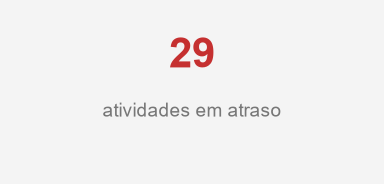

In [288]:
# 1. O cálculo vira de atividades em atraso
total_atrasadas_count = tabela_problemas_global.shape[0]

#desenho de card
fig, ax = plt.subplots(figsize=(4, 2))
ax.patch.set_facecolor('#f4f4f4')
fig.patch.set_facecolor('#f4f4f4')

for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

ax.text(0.5, 0.65, str(total_atrasadas_count), fontsize=30, fontweight='bold', ha='center', color='#C53030', transform=ax.transAxes)
ax.text(0.5, 0.35, 'atividades em atraso', fontsize=14, ha='center', color='#777777', transform=ax.transAxes)

plt.tight_layout()
plt.show()

# Filtro de mentorada



In [289]:
tabela['mentorado'].value_counts()

mentorado
Ana Ribeiro       16
Bruno Costa       10
Felipe Andrade    10
Eduarda Souza     10
Gabriela Pinto    10
Diego Martins      9
Camila Lopes       7
Henrique Alves     4
Milenna Xavier     1
Name: count, dtype: int64

In [290]:
mentorada = tabela[tabela['mentorado'] == 'Ana Ribeiro'].copy()
mentorada.head(16)

,_id,task_id,titulo,descricao,prioridade,user_id,mentorado,area_atuacao,mentor_responsavel,data_criacao,...,data_conclusao,feedback_conclusao_mentorado,createdAt,updatedAt,__v,tempo_conclusao_dias,duracao_em_dias,tempo_no_backlog,meta_execucao,meta_backlog
7,6a2b884993a2aac46c8ba151,8.0,Criar Scripts de Deploy - Sprint 2,Atividade focada em criar o recurso de scripts...,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-04-20,...,2026-04-30,Atividade finalizada com sucesso. A automação ...,NaT,NaT,NaN,10.0,9.0,1.0,8.5,2.0
10,6a2b884993a2aac46c8ba154,11.0,Atualizar Pipeline CI/CD - Sprint 1,Atividade focada em atualizar o recurso de pip...,media,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-03-04,...,2026-03-12,Otimizamos o tempo total do fluxo de integraçã...,NaT,NaT,NaN,8.0,7.0,1.0,11.0,2.0
13,6a2b884993a2aac46c8ba157,14.0,Documentar Tabelas no BD - Sprint 4,Atividade focada em documentar o recurso de ta...,baixa,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-04-15,...,2026-05-01,Dicionário de dados atualizado com sucesso no ...,NaT,NaT,NaN,16.0,15.0,1.0,10.0,2.0
14,6a2b884993a2aac46c8ba158,15.0,Criar Pipeline CI/CD - Sprint 6,Atividade focada em criar o recurso de pipelin...,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-04-21,...,2026-05-10,Pipeline criado do zero para os novos serviços...,NaT,NaT,NaN,19.0,17.0,2.0,8.5,2.0
17,6a2b884993a2aac46c8ba15b,18.0,Implementar Scripts de Deploy - Sprint 1,Atividade focada em implementar o recurso de s...,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-05-12,...,NaT,NaN,NaT,NaT,NaN,NaN,14.0,5.0,8.5,2.0
21,6a2b884993a2aac46c8ba15f,22.0,Documentar Tabelas no BD - Sprint 6,Atividade focada em documentar o recurso de ta...,baixa,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-03-20,...,2026-04-01,Documentação finalizada englobando os esquemas...,NaT,NaT,NaN,12.0,10.0,2.0,10.0,2.0
30,6a2b884993a2aac46c8ba168,31.0,Atualizar Scripts de Deploy - Sprint 6,Atividade focada em atualizar o recurso de scr...,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-05-08,...,2026-05-31,Adicionamos notificações via Slack e tratament...,NaT,NaT,NaN,23.0,20.0,3.0,8.5,2.0
31,6a2b884993a2aac46c8ba169,32.0,Ajustar Pipeline CI/CD - Sprint 9,Atividade focada em ajustar o recurso de pipel...,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-03-05,...,2026-03-13,Ajustamos os gatilhos para evitar deploys acid...,NaT,NaT,NaN,8.0,5.0,3.0,8.5,2.0
34,6a2b884993a2aac46c8ba16c,35.0,Implementar Tabelas no BD - Sprint 5,Atividade focada em implementar o recurso de t...,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-05-14,...,NaT,NaN,NaT,NaT,NaN,NaN,0.0,17.0,8.5,2.0
36,6a2b884993a2aac46c8ba16e,37.0,Otimizar Pipeline CI/CD - Sprint 2,Atividade focada em otimizar o recurso de pipe...,media,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-05-10,...,NaT,NaN,NaT,NaT,NaN,NaN,0.0,21.0,11.0,2.0


In [291]:
mentorada.drop(columns=['descricao', 'mentor_responsavel', 'createdAt','updatedAt','__v', '_id','user_id'], inplace=True, errors='ignore')

In [292]:
mentorada.isnull().sum()

task_id                         0
titulo                          0
prioridade                      0
mentorado                       0
area_atuacao                    0
data_criacao                    0
data_inicio                     3
status_atual                    0
data_conclusao                  6
feedback_conclusao_mentorado    6
tempo_conclusao_dias            6
duracao_em_dias                 0
tempo_no_backlog                0
meta_execucao                   0
meta_backlog                    0
dtype: int64

In [293]:
mentorada.duplicated().sum()

np.int64(0)

In [294]:
mentorada.head(16)

,task_id,titulo,prioridade,mentorado,area_atuacao,data_criacao,data_inicio,status_atual,data_conclusao,feedback_conclusao_mentorado,tempo_conclusao_dias,duracao_em_dias,tempo_no_backlog,meta_execucao,meta_backlog
7,8.0,Criar Scripts de Deploy - Sprint 2,alta,Ana Ribeiro,Data Engineer,2026-04-20,2026-04-21,concluida,2026-04-30,Atividade finalizada com sucesso. A automação ...,10.0,9.0,1.0,8.5,2.0
10,11.0,Atualizar Pipeline CI/CD - Sprint 1,media,Ana Ribeiro,Data Engineer,2026-03-04,2026-03-05,concluida,2026-03-12,Otimizamos o tempo total do fluxo de integraçã...,8.0,7.0,1.0,11.0,2.0
13,14.0,Documentar Tabelas no BD - Sprint 4,baixa,Ana Ribeiro,Data Engineer,2026-04-15,2026-04-16,concluida,2026-05-01,Dicionário de dados atualizado com sucesso no ...,16.0,15.0,1.0,10.0,2.0
14,15.0,Criar Pipeline CI/CD - Sprint 6,alta,Ana Ribeiro,Data Engineer,2026-04-21,2026-04-23,concluida,2026-05-10,Pipeline criado do zero para os novos serviços...,19.0,17.0,2.0,8.5,2.0
17,18.0,Implementar Scripts de Deploy - Sprint 1,alta,Ana Ribeiro,Data Engineer,2026-05-12,2026-05-17,andamento,NaT,NaN,NaN,14.0,5.0,8.5,2.0
21,22.0,Documentar Tabelas no BD - Sprint 6,baixa,Ana Ribeiro,Data Engineer,2026-03-20,2026-03-22,concluida,2026-04-01,Documentação finalizada englobando os esquemas...,12.0,10.0,2.0,10.0,2.0
30,31.0,Atualizar Scripts de Deploy - Sprint 6,alta,Ana Ribeiro,Data Engineer,2026-05-08,2026-05-11,concluida,2026-05-31,Adicionamos notificações via Slack e tratament...,23.0,20.0,3.0,8.5,2.0
31,32.0,Ajustar Pipeline CI/CD - Sprint 9,alta,Ana Ribeiro,Data Engineer,2026-03-05,2026-03-08,concluida,2026-03-13,Ajustamos os gatilhos para evitar deploys acid...,8.0,5.0,3.0,8.5,2.0
34,35.0,Implementar Tabelas no BD - Sprint 5,alta,Ana Ribeiro,Data Engineer,2026-05-14,NaT,pendente,NaT,NaN,NaN,0.0,17.0,8.5,2.0
36,37.0,Otimizar Pipeline CI/CD - Sprint 2,media,Ana Ribeiro,Data Engineer,2026-05-10,NaT,pendente,NaT,NaN,NaN,0.0,21.0,11.0,2.0


In [295]:
mentorada.info()

<class 'pandas.DataFrame'>
Index: 16 entries, 7 to 71
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   task_id                       16 non-null     float64       
 1   titulo                        16 non-null     str           
 2   prioridade                    16 non-null     str           
 3   mentorado                     16 non-null     str           
 4   area_atuacao                  16 non-null     str           
 5   data_criacao                  16 non-null     datetime64[us]
 6   data_inicio                   13 non-null     datetime64[us]
 7   status_atual                  16 non-null     str           
 8   data_conclusao                10 non-null     datetime64[us]
 9   feedback_conclusao_mentorado  10 non-null     str           
 10  tempo_conclusao_dias          10 non-null     float64       
 11  duracao_em_dias               16 non-null     floa

# eda mentorada



In [296]:
concluidas_ment = mentorada[mentorada['status_atual'] == 'concluida']
andamento_ment = mentorada[mentorada['status_atual'] == 'andamento']
pendentes_ment = mentorada[mentorada['status_atual'] == 'pendente']

print("\n--- DURAÇÃO EM DIAS (MÉDIAS) ---")
print(f"Média Conclusão: {concluidas_ment['duracao_em_dias'].mean().round(1)} dias")



print("\n--- TEMPO NO BACKLOG (MÉDIAS) ---")
print(f"Tempo no Backlog (Concluídas): {concluidas_ment['tempo_no_backlog'].mean().round(1)} dias")
print(f"Tempo no Backlog (Em Andamento): {andamento_ment['tempo_no_backlog'].mean().round(1)} dias")
print(f"Tempo no Backlog (Pendentes): {pendentes_ment['tempo_no_backlog'].mean().round(1)} dias")


--- DURAÇÃO EM DIAS (MÉDIAS) ---
Média Conclusão: 13.2 dias

--- TEMPO NO BACKLOG (MÉDIAS) ---
Tempo no Backlog (Concluídas): 2.0 dias
Tempo no Backlog (Em Andamento): 3.3 dias
Tempo no Backlog (Pendentes): 14.0 dias


In [297]:
status_contagem = mentorada['status_atual'].value_counts()
status_percentual = (mentorada['status_atual'].value_counts(normalize=True) * 100).round(1)


df_status = pd.DataFrame({'Quantidade': status_contagem, 'Percentual (%)': status_percentual})
display(df_status)



,Quantidade,Percentual (%)
status_atual,,
concluida,10,62.5
andamento,3,18.8
pendente,3,18.8


In [298]:
media_por_prioridade = mentorada.groupby('prioridade')['duracao_em_dias'].mean().round(1)
print( f'A média de dias por prioridade é: {media_por_prioridade}')

mediana_por_prioridade = mentorada.groupby('prioridade')['duracao_em_dias'].median().round(1)
print(f'A mediana de dias por prioridade é: {mediana_por_prioridade}')

A média de dias por prioridade é: prioridade
alta      9.3
baixa    12.5
media     8.7
Name: duracao_em_dias, dtype: float64
A mediana de dias por prioridade é: prioridade
alta      9.0
baixa    12.5
media     7.0
Name: duracao_em_dias, dtype: float64


In [299]:
mentorada.describe()

,task_id,data_criacao,data_inicio,data_conclusao,tempo_conclusao_dias,duracao_em_dias,tempo_no_backlog,meta_execucao,meta_backlog
count,16.000000,16,13,10,10.000000,16.000000,16.000000,16.00000,16.0
mean,37.062500,2026-04-19 09:00:00,2026-04-15 07:23:04.615384,2026-04-16 21:36:00,15.200000,9.562500,4.500000,9.15625,2.0
min,8.000000,2026-03-03 00:00:00,2026-03-04 00:00:00,2026-03-12 00:00:00,8.000000,0.000000,1.000000,8.50000,2.0
25%,17.250000,2026-03-21 12:00:00,2026-03-22 00:00:00,2026-03-25 06:00:00,10.500000,4.250000,1.000000,8.50000,2.0
50%,33.500000,2026-04-22 12:00:00,2026-04-21 00:00:00,2026-04-17 12:00:00,15.000000,9.500000,3.000000,8.50000,2.0
75%,54.000000,2026-05-12 12:00:00,2026-05-11 00:00:00,2026-05-07 18:00:00,19.750000,15.500000,4.000000,10.00000,2.0
max,72.000000,2026-05-27 00:00:00,2026-05-29 00:00:00,2026-05-31 00:00:00,23.000000,20.000000,21.000000,11.00000,2.0
std,22.040777,NaN,NaN,NaN,5.652925,7.183024,5.842374,1.04433,0.0


In [300]:
Q1 = mentorada['duracao_em_dias'].quantile(0.25)
Q3 = mentorada['duracao_em_dias'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

print(f"\nLimite Superior de dias normais: {limite_superior}") #n é uma boa medida nesse caso


Limite Superior de dias normais: 32.375


In [301]:
historico = tabela[tabela['status_atual'] == 'concluida']
mediana_geral_por_prioridade = historico.groupby('prioridade')['duracao_em_dias'].median().round(1) 

# mapear pela mediana visando uma avaliação mais realista, já que a média pode ser distorcida por outliers (tarefas que demoraram muito mais do que o normal). A mediana nos dá uma visão mais robusta do tempo típico de conclusão para cada prioridade.
tarefas_n_concluida = mentorada[mentorada['status_atual'].isin(['andamento', 'pendente'])].copy()
tarefas_n_concluida['tempo_limite'] = tarefas_n_concluida['prioridade'].map(mediana_geral_por_prioridade) 

print("\n--- AVALIAÇÃO DE GARGALO FUTURO ---")
display(tarefas_n_concluida[['titulo', 'status_atual', 'prioridade', 'duracao_em_dias', 'tempo_limite']])


--- AVALIAÇÃO DE GARGALO FUTURO ---


,titulo,status_atual,prioridade,duracao_em_dias,tempo_limite
17,Implementar Scripts de Deploy - Sprint 1,andamento,alta,14.0,8.5
34,Implementar Tabelas no BD - Sprint 5,pendente,alta,0.0,8.5
36,Otimizar Pipeline CI/CD - Sprint 2,pendente,media,0.0,11.0
49,Criar Pipeline CI/CD - Sprint 7,andamento,alta,2.0,8.5
56,Otimizar Scripts de Deploy - Sprint 8,pendente,alta,0.0,8.5
66,Atualizar Scripts de Deploy - Sprint 9,andamento,alta,5.0,8.5


# KPIs


##card - valores totais, médias gerais, ou algo muito expecidfico

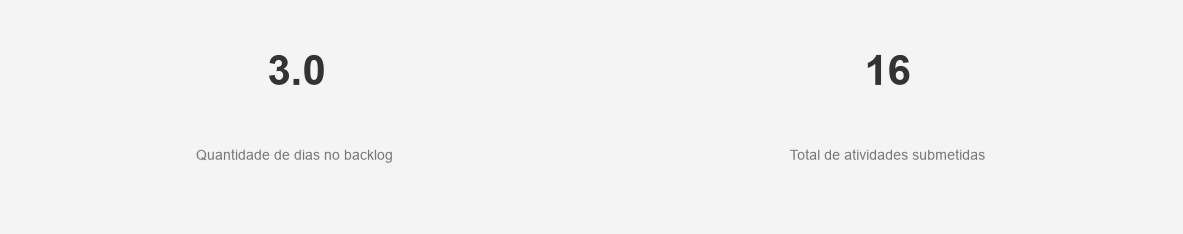

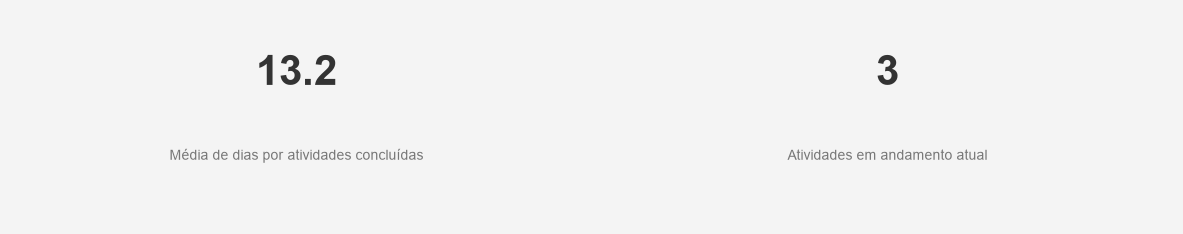

In [302]:
import json
totalatividades = mentorada['status_atual'].count()
medianaconclusao = mentorada['tempo_no_backlog'].median()
mediaconclusao = mentorada[mentorada['status_atual'] == 'concluida']['duracao_em_dias'].mean().round(1)
TotalAtvAndamento = len(mentorada[mentorada['status_atual'] == 'andamento'])

# Plotagem dos Cards 1 e 2 (Backlog e Total)
fig, axes = plt.subplots(1, 2, figsize=(12, 2.5))
fig.patch.set_facecolor('#f4f4f4')

for ax, valor, texto in zip(axes, [medianaconclusao, totalatividades], 
                             ['Quantidade de dias no backlog ', 'Total de atividades submetidas']): #esse dado vem da mediana, por ser a parte mais representativa do tempo que as atividades ficam no backlog, já que a média pode ser distorcida por outliers (tarefas que ficaram muito tempo no backlog)
    ax.patch.set_facecolor('#f4f4f4')
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    ax.text(0.5, 0.65, str(valor), fontsize=30, fontweight='bold', ha='center', color='#333333', transform=ax.transAxes)
    ax.text(0.5, 0.30, texto, fontsize=10, ha='center', color='#777777', transform=ax.transAxes)

plt.tight_layout()
plt.show()

# Plotagem dos Cards 3 e 4 (Tempo Médio de Entrega e WIP)
fig, axes = plt.subplots(1, 2, figsize=(12, 2.5))
fig.patch.set_facecolor('#f4f4f4')

for ax, valor, texto in zip(axes, [mediaconclusao, TotalAtvAndamento], 
                             ['Média de dias por atividades concluídas', 'Atividades em andamento atual']):
    ax.patch.set_facecolor('#f4f4f4')
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    ax.text(0.5, 0.65, str(valor), fontsize=30, fontweight='bold', ha='center', color='#333333', transform=ax.transAxes)
    ax.text(0.5, 0.30, texto, fontsize=10, ha='center', color='#777777', transform=ax.transAxes)

plt.tight_layout()
plt.show()



## PIZZA GRAFICO



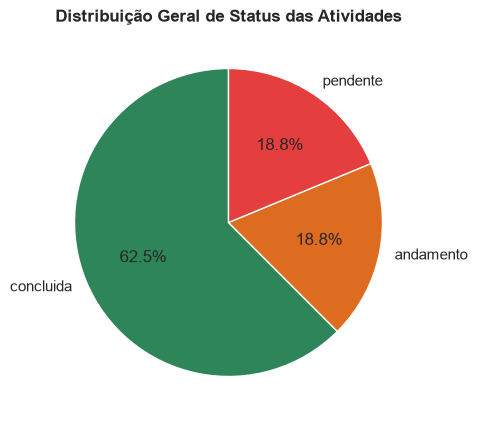

In [303]:

status_andamento = mentorada['status_atual'].value_counts()

cores_status = {
    'concluida': '#2f855a',  # Verde
    'andamento': '#dd6b20',  # Laranja
    'pendente': '#e53e3e'   # Vermelho
}
lista_cores = [cores_status[status] for status in status_andamento.index]


plt.figure(figsize=(5, 5))
plt.pie(status_andamento, labels=status_andamento.index, autopct='%1.1f%%', colors=lista_cores, startangle=90)
plt.title('Distribuição Geral de Status das Atividades', fontsize=12, fontweight='bold')
plt.savefig('grafico_status.png', transparent=True)
plt.show()



GRAFICO DINAMICO

In [ ]:
import plotly.express as px

# 1. BASE DE REFERÊNCIA (Agora usando a MEDIANA para alinhar com as tabelas de SLA)
concluidas_equipe = tabela[tabela['status_atual'] == 'concluida']

# Substituímos .mean() por .median()
mediana_equipe = concluidas_equipe['duracao_em_dias'].median() 
teto_do_grafico = concluidas_equipe['duracao_em_dias'].max() + 2

# 2. MAPA DE CORES
mapa_de_cores = {
    'alta': '#E74C3C',    # Vermelho Alerta
    'Alta': '#E74C3C',
    'média': '#F39C12',   # Laranja/Amarelo Atenção
    'media': '#F39C12',
    'Média': '#F39C12',
    'baixa': '#2ECC71',   # Verde Tranquilo
    'Baixa': '#2ECC71'
}

# 3. FUNÇÃO DO GRÁFICO
def criar_grafico_evolucao(dataset_alvo, titulo_do_grafico):
    df_plot = dataset_alvo[dataset_alvo['status_atual'] == 'concluida'].copy()
    if df_plot.empty:
        print("Nenhuma tarefa concluída para plotar no gráfico de evolução.")
        return None
        
    df_plot['sprint_num'] = df_plot['titulo'].str.extract(r'Sprint (\d+)').fillna(0).astype(int)
    df_plot['nome_sprint'] = df_plot['titulo'].str.extract(r'(Sprint \d+)').fillna('Sem Sprint')
    df_plot = df_plot.sort_values('sprint_num')

    fig = px.scatter(
        df_plot, x='nome_sprint', y='duracao_em_dias', color='prioridade',
        color_discrete_map=mapa_de_cores, hover_data=['titulo', 'mentorado'],
        title=titulo_do_grafico,
        labels={'duracao_em_dias': 'Dias Gastos', 'nome_sprint': 'Sprint', 'prioridade': 'Dificuldade'}
    )
    
    # ATUALIZAR PARA MEDIANA PARA CONSIDERAR VALORES MAIS EQUILIBRADOS
    fig.add_hline(y=mediana_equipe, line_dash="dash", line_color="gray",
                  annotation_text=f"Mediana Geral da Equipe ({mediana_equipe:.1f} dias)", 
                  annotation_position="bottom right")
                  
    fig.update_traces(marker=dict(size=14, opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))
    fig.update_yaxes(range=[0, teto_do_grafico])
    return fig

# Plotando
grafico_ana = criar_grafico_evolucao(mentorada, "Evolução Individual X Mediana da Equipe")
if grafico_ana: grafico_ana.show()

##Tabela

In [ ]:
import numpy as np

# 1. CRIAR AS METAS JUSTAS BASEADAS NA EQUIPE TODA ATRAVES DA MEDIANA
historico_geral = tabela[tabela['status_atual'] == 'concluida'].copy()

meta_execucao_prioridade = historico_geral.groupby('prioridade')['duracao_em_dias'].median().round(1)
meta_backlog_prioridade = historico_geral.groupby('prioridade')['tempo_no_backlog'].median().round(1)

# Injetando as DUAS metas na tabela específica da Ana
mentorada['meta_execucao'] = mentorada['prioridade'].map(meta_execucao_prioridade)
mentorada['meta_backlog'] = mentorada['prioridade'].map(meta_backlog_prioridade)

# 2. FILTRAR AS ATIVAS DA ANA
atvd_ativa_ana = mentorada[mentorada['status_atual'].isin(['andamento', 'pendente'])].copy()

# 3. CRIAR OS RELÓGIOS INTELIGENTES (Dias Decorridos e Meta Dinâmica)
atvd_ativa_ana['dias_decorridos'] = np.where(
    atvd_ativa_ana['status_atual'] == 'pendente',
    atvd_ativa_ana['tempo_no_backlog'],
    atvd_ativa_ana['duracao_em_dias']
)

atvd_ativa_ana['meta_dias'] = np.where(
    atvd_ativa_ana['status_atual'] == 'pendente',
    atvd_ativa_ana['meta_backlog'],
    atvd_ativa_ana['meta_execucao']
)

# 4. A FUNÇÃO DE DIAGNÓSTICO (Agora simplificada usando as colunas inteligentes)
def sinalizar_status_ana(linha): 
    status = linha['status_atual']
    dias = linha['dias_decorridos'] 
    meta = linha['meta_dias'] # Usa a meta inteligente!

    if status == 'pendente':
        if dias > (meta * 2): return '🔴 Crítico (Fila)'
        elif dias > meta:     return '🟡 Alerta (Fila)'
        else:                 return '⚪ Pendente Normal'

    elif status == 'andamento':
        if dias > (meta * 2): return '🔴 Crítico (Execução)'
        elif dias > meta:     return '🟡 Atrasado (Execução)'
        else:                 return '🟢 Dentro do Prazo'
        
    return '✔️ Entregue'

# 5. APLICAR A FUNÇÃO DE DIAGNÓSTICO
atvd_ativa_ana['Diagnostico'] = atvd_ativa_ana.apply(sinalizar_status_ana, axis=1)

# 6. MONTAR A TABELA FINAL LIMPA PARA O CLIENTE (Com a dupla ordenação de gravidade)
tabela_completa_ana = atvd_ativa_ana[[
    'titulo', 'prioridade', 'status_atual', 
    'dias_decorridos', 'meta_dias', 'Diagnostico'
]].sort_values(by=['Diagnostico', 'dias_decorridos'], ascending=[True, False])

# 7. SEPARAR AS TABELAS PARA O DASHBOARD
condicao_problema_ana = tabela_completa_ana['Diagnostico'].str.contains('🔴|🟡')
tabela_problemas_ana = tabela_completa_ana[condicao_problema_ana]

condicao_saudavel_ana = tabela_completa_ana['Diagnostico'].str.contains('🟢|⚪')
tabela_saudaveis_ana = tabela_completa_ana[condicao_saudavel_ana]

print("=== 🚨 TABELA DE INTERVENÇÃO (ATRASOS/CRÍTICOS) ===")
display(tabela_problemas_ana)

print("\n=== 🟢 TABELA DE FLUXO SAUDÁVEL ===")
display(tabela_saudaveis_ana)

=== 🚨 TABELA DE INTERVENÇÃO (ATRASOS/CRÍTICOS) ===


,titulo,prioridade,status_atual,dias_decorridos,meta_dias,Diagnostico
36,Otimizar Pipeline CI/CD - Sprint 2,media,pendente,21.0,2.0,🔴 Crítico (Fila)
34,Implementar Tabelas no BD - Sprint 5,alta,pendente,17.0,2.0,🔴 Crítico (Fila)
56,Otimizar Scripts de Deploy - Sprint 8,alta,pendente,4.0,2.0,🟡 Alerta (Fila)
17,Implementar Scripts de Deploy - Sprint 1,alta,andamento,14.0,8.5,🟡 Atrasado (Execução)



=== 🟢 TABELA DE FLUXO SAUDÁVEL ===


,titulo,prioridade,status_atual,dias_decorridos,meta_dias,Diagnostico
66,Atualizar Scripts de Deploy - Sprint 9,alta,andamento,5.0,8.5,🟢 Dentro do Prazo
49,Criar Pipeline CI/CD - Sprint 7,alta,andamento,2.0,8.5,🟢 Dentro do Prazo


TABELA PARA VISUALIZAR OS SALDOS DE TODOS OS MENTORADOS E SUAS ATIVIDADES Q ESTAO FORA DA

In [306]:
analise_geral_limpa = tabela.to_csv('analise_geral_limpa.csv', index=False)
print("✅ Arquivo 'analise_geral_limpa.csv' gerado com sucesso!")

✅ Arquivo 'analise_geral_limpa.csv' gerado com sucesso!
